In [ ]:
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')

# Download dataset

url = "https://raw.githubusercontent.com/abbylmm/fake_job_posting/main/data/fake_job_postings.csv"
df = pd.read_csv(url)

print("Shape:" , df.shape)
df.head()

Shape: (17880, 18)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

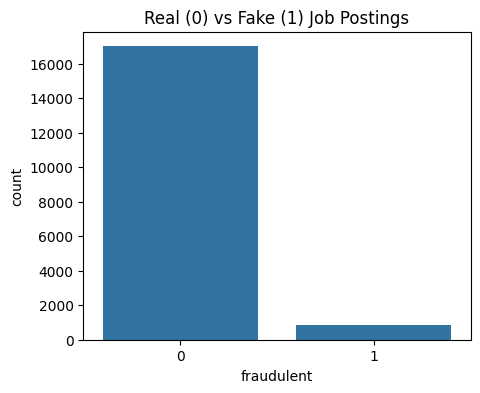

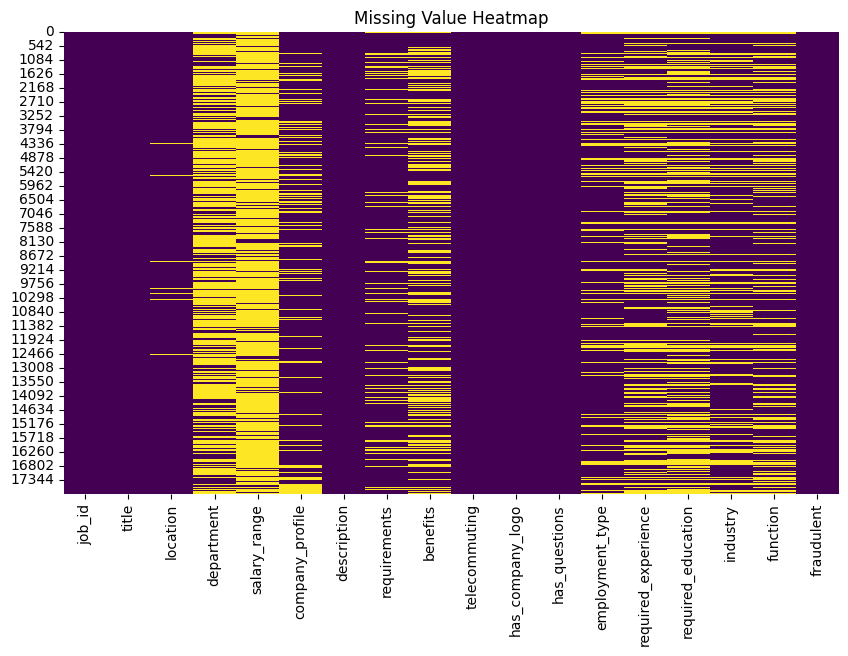

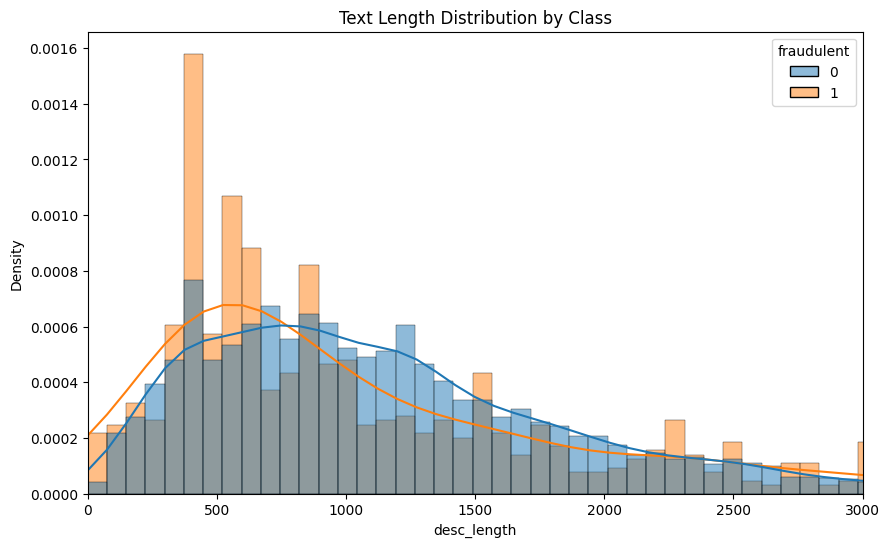

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print(df.info())
print("\nMissing values: \n", df.isnull().sum())
print("\nClass distribution: \n", df['fraudulent'].value_counts())
print("\nClass % :\n", df['fraudulent'].value_counts(normalize=True)*100)

# Visualize class imbalance
plt.figure(figsize=(5,4))
sns.countplot(x='fraudulent', data=df)
plt.title("Real (0) vs Fake (1) Job Postings")
plt.show()

# Missing value heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Value Heatmap")
plt.show()

# Text length distribution by class
df['description'] = df['description'].fillna('')
df['desc_length'] = df['description'].apply(len)
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='desc_length', hue='fraudulent', kde=True, stat='density', common_norm=False)
plt.title("Text Length Distribution by Class")
plt.xlim(0, 3000)
plt.show()




In [ ]:
# Fill missing values for text and categorical columns
text_cols = ['title', 'company_profile', 'description', 'requirements', 'benefits']
for col in text_cols:
    df[col] = df[col].fillna('')

cat_cols = ['employment_type', 'required_experience', 'required_education', 'industry', 'function', 'location']
for col in cat_cols:
    df[col] = df[col].fillna('Unknown')

# Combine key textual attributes into a single field
df['text'] = (
    df['title'] + ' ' +
    df['company_profile'] + ' ' +
    df['description'] + ' ' +
    df['requirements'] + ' ' +
    df['benefits']
)

# Text cleaning function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)   # remove URLs
    text = re.sub(r'#url_\w+', '', text)                   # dataset-specific placeholder
    text = re.sub(r'\d+', '', text)                        # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()                # remove extra whitespace
    return text

df['clean_text'] = df['text'].apply(clean_text)

# Structured/meta features that may add signal
df['has_company_logo'] = df['has_company_logo'].fillna(0)
df['has_questions'] = df['has_questions'].fillna(0)
df['telecommuting'] = df['telecommuting'].fillna(0)
df['text_length'] = df['clean_text'].apply(len)

df[['clean_text', 'fraudulent']].head()

,clean_text,fraudulent
0,marketing intern were food and weve created a ...,0
1,customer service cloud video production second...,0
2,commissioning machinery assistant cma valor se...,0
3,account executive washington dc our passion fo...,0
4,bill review manager spotsource solutions llc i...,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

X = df['clean_text']
y = df['fraudulent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0], "Test size:", X_test.shape[0])

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# CountVectorizer (for comparison)
cv = CountVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.transform(X_test)

print("TF-IDF shape:", X_train_tfidf.shape)

Train size: 14304 Test size: 3576
TF-IDF shape: (14304, 5000)


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_tfidf_bal, y_train_bal = smote.fit_resample(X_train_tfidf, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_train_bal).value_counts().to_dict())

Before SMOTE: {0: 13611, 1: 693}
After SMOTE: {0: 13611, 1: 13611}


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    "Linear SVM": LinearSVC(class_weight='balanced', max_iter=5000)
}

results = {}

for name, model in models.items():
    model.fit(X_train_tfidf_bal, y_train_bal)
    y_pred = model.predict(X_test_tfidf)

    # decision_function/predict_proba for AUC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_tfidf)[:, 1]
    else:
        y_score = model.decision_function(X_test_tfidf)

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_score),
        "model": model,
        "y_pred": y_pred,
        "y_score": y_score
    }
    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred, target_names=['Real','Fake']))


===== Logistic Regression =====
              precision    recall  f1-score   support

        Real       0.99      0.98      0.99      3403
        Fake       0.72      0.87      0.79       173

    accuracy                           0.98      3576
   macro avg       0.86      0.93      0.89      3576
weighted avg       0.98      0.98      0.98      3576


===== Naive Bayes =====
              precision    recall  f1-score   support

        Real       1.00      0.91      0.95      3403
        Fake       0.35      0.94      0.51       173

    accuracy                           0.91      3576
   macro avg       0.67      0.92      0.73      3576
weighted avg       0.97      0.91      0.93      3576


===== Random Forest =====
              precision    recall  f1-score   support

        Real       0.98      1.00      0.99      3403
        Fake       1.00      0.67      0.80       173

    accuracy                           0.98      3576
   macro avg       0.99      0.84      0.90

                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.9773     0.7190  0.8728  0.7885   0.9832
Naive Bayes            0.9139     0.3529  0.9364  0.5127   0.9772
Random Forest          0.9841     1.0000  0.6705  0.8028   0.9832
Linear SVM             0.9824     0.8235  0.8092  0.8163   0.9795


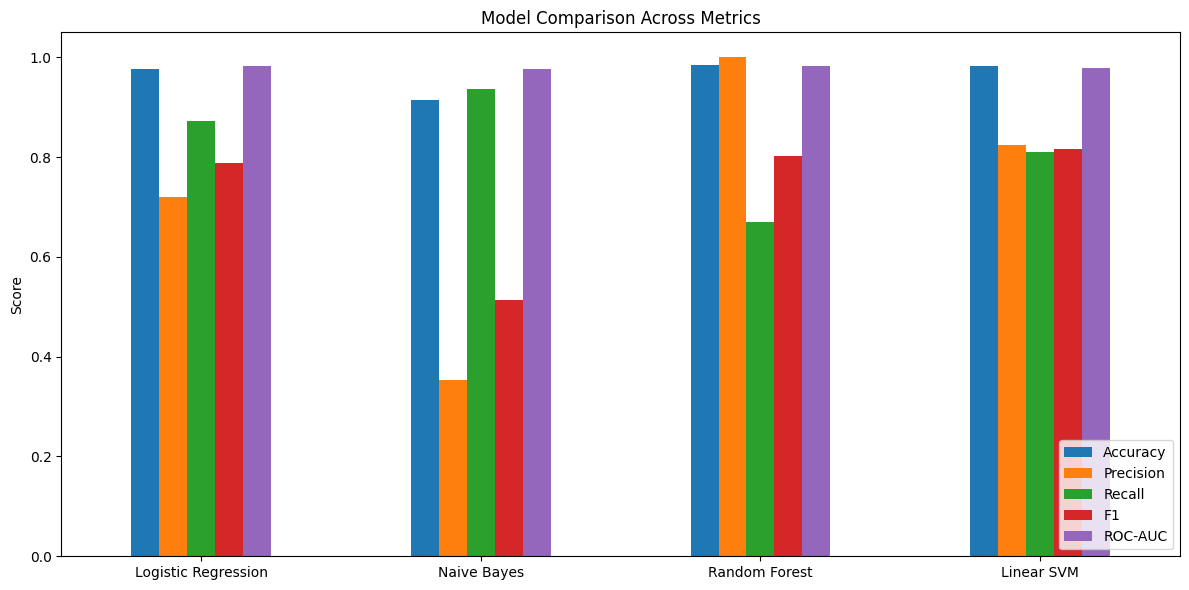

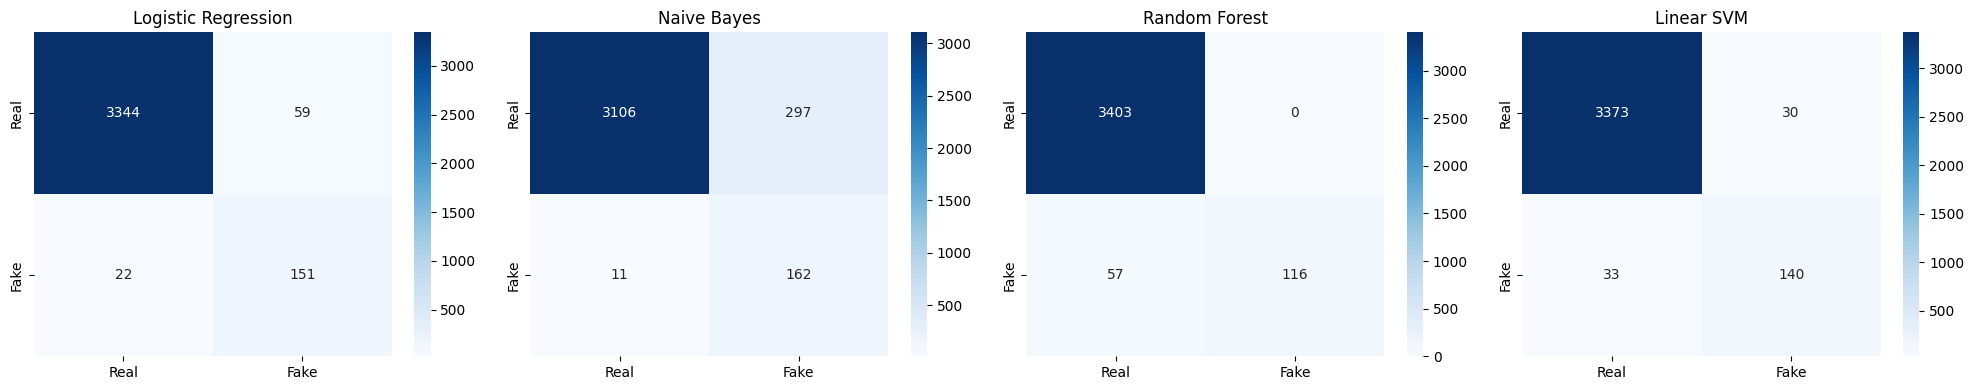

In [ ]:
results_df = pd.DataFrame({k: {m: v for m, v in val.items() if m in
                            ['Accuracy','Precision','Recall','F1','ROC-AUC']}
                            for k, val in results.items()}).T

print(results_df.round(4))

results_df[['Accuracy','Precision','Recall','F1','ROC-AUC']].plot(
    kind='bar', figsize=(12,6), title="Model Comparison Across Metrics"
)
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, len(models), figsize=(20,4))
for ax, (name, val) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, val['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
    ax.set_title(name)
plt.tight_layout()
plt.show()

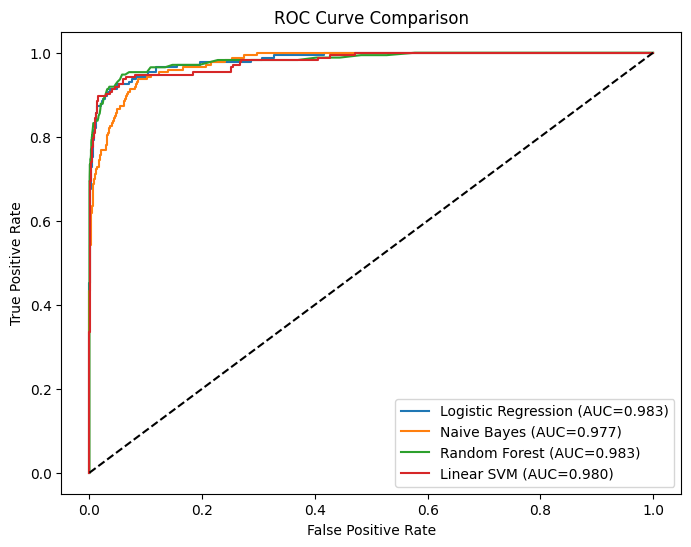

In [ ]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))
for name, val in results.items():
    fpr, tpr, _ = roc_curve(y_test, val['y_score'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={val['ROC-AUC']:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
log_reg = results["Logistic Regression"]["model"]
feature_names = np.array(tfidf.get_feature_names_out())
coefs = log_reg.coef_[0]

top_fraud_idx = np.argsort(coefs)[-20:]
top_real_idx = np.argsort(coefs)[:20]

print("Top words indicating FRAUDULENT postings:")
for i in reversed(top_fraud_idx):
    print(f"  {feature_names[i]:20s} {coefs[i]:.3f}")

print("\nTop words indicating LEGITIMATE postings:")
for i in top_real_idx:
    print(f"  {feature_names[i]:20s} {coefs[i]:.3f}")

Top words indicating FRAUDULENT postings:
  aptitude             4.946
  earn                 4.721
  data entry           4.516
  money                4.393
  high school          4.354
  apply                4.263
  subsea               4.001
  engineering          3.808
  oil gas              3.765
  cash                 3.546
  clerk                3.438
  financing            3.405
  entry                3.400
  type                 3.361
  work home            3.281
  signing              3.238
  compensation package 3.214
  accountant           3.170
  word                 3.161
  hospital             3.141

Top words indicating LEGITIMATE postings:
  team                 -4.731
  companies            -4.362
  english              -3.410
  digital              -3.241
  clients              -3.237
  recruitment          -3.195
  growing              -3.135
  based                -3.001
  fun                  -2.955
  search               -2.939
  software             -2.902
  web

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['liblinear']
}

grid = GridSearchCV(LogisticRegression(class_weight='balanced', max_iter=1000),
                     param_grid, scoring='f1', cv=3, n_jobs=-1)
grid.fit(X_train_tfidf_bal, y_train_bal)

print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

best_lr = grid.best_estimator_
y_pred_best = best_lr.predict(X_test_tfidf)
print(classification_report(y_test, y_pred_best, target_names=['Real','Fake']))

Best params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1: 0.9923078921571138
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      3403
        Fake       0.82      0.87      0.84       173

    accuracy                           0.98      3576
   macro avg       0.91      0.93      0.92      3576
weighted avg       0.98      0.98      0.98      3576



In [ ]:
def predict_job_posting(title, company_profile, description, requirements, benefits,
                         model=None, vectorizer=tfidf):
    """
    Predicts whether a job posting is fraudulent or legitimate.
    Returns label and confidence score.
    """
    if model is None:
        model = results["Logistic Regression"]["model"]  # default best-performing model

    combined_text = f"{title} {company_profile} {description} {requirements} {benefits}"
    cleaned = clean_text(combined_text)
    vec = vectorizer.transform([cleaned])

    pred = model.predict(vec)[0]
    if hasattr(model, "predict_proba"):
        conf = model.predict_proba(vec)[0][pred]
    else:
        conf = abs(model.decision_function(vec)[0])

    label = "FRAUDULENT" if pred == 1 else "LEGITIMATE"
    return label, round(float(conf), 3)

# Example usage
sample_title = "Work From Home Data Entry - Earn $5000/week!"
sample_profile = ""
sample_desc = "No experience needed. Just send your bank details to get started immediately."
sample_req = "Must have a computer and internet."
sample_benefits = "Guaranteed high pay, no interview required."

label, confidence = predict_job_posting(sample_title, sample_profile, sample_desc,
                                         sample_req, sample_benefits)
print(f"Prediction: {label}  (confidence: {confidence})")

Prediction: FRAUDULENT  (confidence: 0.989)
